<a href="https://colab.research.google.com/github/Jibin1902/pythonassgn/blob/main/keralaroad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('/content/kerala_road_accidents.csv')

In [ ]:
df

/usr/local/lib/python3.10/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Accident ID,Date,Time,Location,Vehicle Involved,Weather Conditions,Road Type,Injury Severity,Cause,Number of Vehicles,Number of Injuries,Number of Fatalities
0,1.0,NaN,NaN,Palakkad,Car,Foggy,City road,Minor,Overspeeding,2.0,5.0,4.0
1,2.0,2023-01-01,01:00:00,Thrissur,Bus,Cloudy,City road,Minor,Distracted driving,1.0,1.0,2.0
2,3.0,2023-01-01,NaN,Kannur,NaN,Clear,Main road,Major,Animal crossing,2.0,NaN,4.0
3,4.0,2023-01-01,03:00:00,Kollam,Bus,NaN,City road,Fatal,Animal crossing,3.0,6.0,3.0
4,5.0,2023-01-01,04:00:00,NaN,Two-wheeler,Clear,Highway,Major,Reckless driving,2.0,NaN,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996.0,2025-04-13,03:00:00,NaN,Bicycle,Clear,Main road,Minor,Overspeeding,4.0,0.0,0.0
19996,19997.0,2025-04-13,04:00:00,Kochi,NaN,Cloudy,Rural road,NaN,Overspeeding,3.0,9.0,NaN
19997,19998.0,2025-04-13,05:00:00,Kollam,Bicycle,Cloudy,Rural road,Minor,Overspeeding,NaN,8.0,NaN
19998,19999.0,NaN,06:00:00,Kottayam,Bicycle,NaN,NaN,Minor,Drunk driving,1.0,1.0,1.0


In [ ]:
print(df.columns)
df = pd.read_csv('/content/kerala_road_accidents.csv', delimiter=',')
# Access and calculate nunique for each column separately
road_type_unique = df['Road Type'].nunique()
location_unique = df['Location'].nunique()
time_unique = df['Time'].nunique()
date_unique = df['Date'].nunique()
accident_id_unique = df['Accident ID'].nunique()

# Print the unique values for each column
print(f"Road Type Unique Values: {road_type_unique}")
print(f"Location Unique Values: {location_unique}")
print(f"Time Unique Values: {time_unique}")
print(f"Date Unique Values: {date_unique}")
print(f"Accident ID Unique Values: {accident_id_unique}")

Index(['Accident ID', 'Date', 'Time', 'Location', 'Vehicle Involved',
       'Weather Conditions', 'Road Type', 'Injury Severity', 'Cause',
       'Number of Vehicles', 'Number of Injuries', 'Number of Fatalities'],
      dtype='object')
Road Type Unique Values: 4
Location Unique Values: 9
Time Unique Values: 24
Date Unique Values: 834
Accident ID Unique Values: 18000


In [ ]:
# Drop the specified columns
columns_to_drop = ['Accident ID', 'Date', 'Time', 'Location', 'Road Type']
df = df.drop(columns=columns_to_drop)

# Save the modified dataset to a new file
df.to_csv('modified_dataset.csv', index=False)

print("Columns dropped and file saved as 'modified_dataset.csv'")



Columns dropped and file saved as 'modified_dataset.csv'


In [ ]:
df.head()

,Vehicle Involved,Weather Conditions,Injury Severity,Cause,Number of Vehicles,Number of Injuries,Number of Fatalities
0,Car,Foggy,Minor,Overspeeding,2.0,5.0,4.0
1,Bus,Cloudy,Minor,Distracted driving,1.0,1.0,2.0
2,NaN,Clear,Major,Animal crossing,2.0,NaN,4.0
3,Bus,NaN,Fatal,Animal crossing,3.0,6.0,3.0
4,Two-wheeler,Clear,Major,Reckless driving,2.0,NaN,4.0


In [ ]:
# replace all the null values in every columns
for column in df.columns:
    most_frequent_value = df[column].mode()[0]
    df[column].fillna(most_frequent_value, inplace=True)

<ipython-input-7-1ee16d5ee24f>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(most_frequent_value, inplace=True)


In [ ]:
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (20000, 7)


In [ ]:
print("First 5 rows of the dataset:")
print(df.head())



First 5 rows of the dataset:
  Vehicle Involved Weather Conditions Injury Severity               Cause  \
0              Car              Foggy           Minor        Overspeeding   
1              Bus             Cloudy           Minor  Distracted driving   
2          Bicycle              Clear           Major     Animal crossing   
3              Bus              Rainy           Fatal     Animal crossing   
4      Two-wheeler              Clear           Major    Reckless driving   

   Number of Vehicles  Number of Injuries  Number of Fatalities  
0                 2.0                 5.0                   4.0  
1                 1.0                 1.0                   2.0  
2                 2.0                 0.0                   4.0  
3                 3.0                 6.0                   3.0  
4                 2.0                 0.0                   4.0  


In [ ]:
print("\nBasic Statistical Summary:")
print(df.describe())




Basic Statistical Summary:
       Number of Vehicles  Number of Injuries  Number of Fatalities
count        20000.000000        20000.000000          20000.000000
mean             2.660200            4.037700              1.896650
std              1.154471            3.051744              1.376577
min              1.000000            0.000000              0.000000
25%              2.000000            1.000000              1.000000
50%              3.000000            4.000000              2.000000
75%              4.000000            7.000000              3.000000
max              4.000000            9.000000              4.000000


In [ ]:
print("\nChecking for Missing Values:")
print(df.isnull().sum())


Checking for Missing Values:
Vehicle Involved        0
Weather Conditions      0
Injury Severity         0
Cause                   0
Number of Vehicles      0
Number of Injuries      0
Number of Fatalities    0
dtype: int64


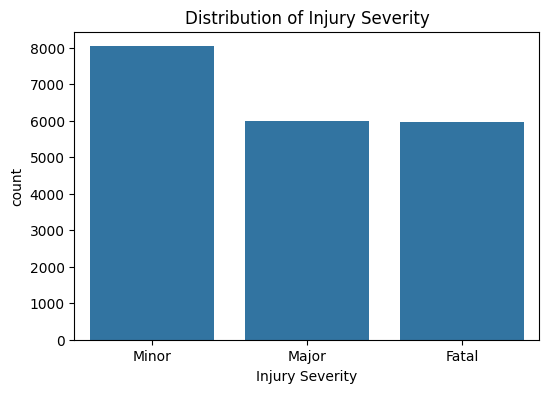

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Injury Severity', data=df)
plt.title('Distribution of Injury Severity')
plt.show()

In [ ]:
df.head()

,Vehicle Involved,Weather Conditions,Injury Severity,Cause,Number of Vehicles,Number of Injuries,Number of Fatalities
0,Car,Foggy,Minor,Overspeeding,2.0,5.0,4.0
1,Bus,Cloudy,Minor,Distracted driving,1.0,1.0,2.0
2,Bicycle,Clear,Major,Animal crossing,2.0,0.0,4.0
3,Bus,Rainy,Fatal,Animal crossing,3.0,6.0,3.0
4,Two-wheeler,Clear,Major,Reckless driving,2.0,0.0,4.0


In [ ]:
columns = [
    'Vehicle Involved',
    'Weather Conditions',
    'Injury Severity',
    'Cause',
    'Number of Vehicles',
    'Number of Injuries',
    'Number of Fatalities'
]

# print unique values
for column in columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print("\n")



Unique values in 'Vehicle Involved':
['Car' 'Bus' 'Bicycle' 'Two-wheeler' 'Truck' 'Van' 'Auto Rickshaw']


Unique values in 'Weather Conditions':
['Foggy' 'Cloudy' 'Clear' 'Rainy' 'Windy']


Unique values in 'Injury Severity':
['Minor' 'Major' 'Fatal']


Unique values in 'Cause':
['Overspeeding' 'Distracted driving' 'Animal crossing' 'Reckless driving'
 'Brake failure' 'Drunk driving']


Unique values in 'Number of Vehicles':
[2. 1. 3. 4.]


Unique values in 'Number of Injuries':
[5. 1. 0. 6. 4. 9. 3. 8. 2. 7.]


Unique values in 'Number of Fatalities':
[4. 2. 3. 1. 0.]




In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Define the columns you want to label encode
columns_to_encode = ['Vehicle Involved', 'Weather Conditions', 'Injury Severity', 'Cause']

# Loop through the columns and apply label encoding
for column in columns_to_encode:
  df[column] = le.fit_transform(df[column])

# Print the updated dataframe to verify the encoding
print(df.head())

   Vehicle Involved  Weather Conditions  Injury Severity  Cause  \
0                 3                   2                2      4   
1                 2                   1                2      2   
2                 1                   0                1      0   
3                 2                   3                0      0   
4                 5                   0                1      5   

   Number of Vehicles  Number of Injuries  Number of Fatalities  
0                 2.0                 5.0                   4.0  
1                 1.0                 1.0                   2.0  
2                 2.0                 0.0                   4.0  
3                 3.0                 6.0                   3.0  
4                 2.0                 0.0                   4.0  


In [ ]:
df.head()

,Vehicle Involved,Weather Conditions,Injury Severity,Cause,Number of Vehicles,Number of Injuries,Number of Fatalities
0,3,2,2,4,2.0,5.0,4.0
1,2,1,2,2,1.0,1.0,2.0
2,1,0,1,0,2.0,0.0,4.0
3,2,3,0,0,3.0,6.0,3.0
4,5,0,1,5,2.0,0.0,4.0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df[['Vehicle Involved', 'Weather Conditions', 'Cause', 'Number of Vehicles', 'Number of Injuries', 'Number of Fatalities']]
y = df['Injury Severity']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


Accuracy: 0.34
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.27      0.28      1142
           1       0.29      0.25      0.27      1202
           2       0.40      0.45      0.42      1656

    accuracy                           0.34      4000
   macro avg       0.32      0.32      0.32      4000
weighted avg       0.33      0.34      0.33      4000



In [ ]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.2f}")
print(classification_report(y_test, y_pred_gb))

# XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(classification_report(y_test, y_pred_xgb))


Gradient Boosting Accuracy: 0.40
              precision    recall  f1-score   support

           0       0.32      0.04      0.07      1142
           1       0.24      0.03      0.05      1202
           2       0.41      0.92      0.57      1656

    accuracy                           0.40      4000
   macro avg       0.32      0.33      0.23      4000
weighted avg       0.33      0.40      0.27      4000

XGBoost Accuracy: 0.36
              precision    recall  f1-score   support

           0       0.29      0.23      0.25      1142
           1       0.30      0.21      0.25      1202
           2       0.41      0.56      0.48      1656

    accuracy                           0.36      4000
   macro avg       0.33      0.33      0.33      4000
weighted avg       0.34      0.36      0.34      4000



In [ ]:
import pickle
from sklearn.ensemble import GradientBoostingClassifier
with open('gb_model.pkl', 'wb') as file:
    pickle.dump(gb, file)

from google.colab import files
files.download('gb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y)
X = df[['Vehicle Involved', 'Weather Conditions', 'Cause', 'Number of Vehicles', 'Number of Injuries', 'Number of Fatalities']]
y = df['Injury Severity']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Train the model using grid search
grid_search.fit(X_train, y_train)

# Get the best estimator (best combination of hyperparameters)
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate a classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

# Print the best hyperparameters
print("Best Hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)


Fitting 3 folds for each of 162 candidates, totalling 486 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Accuracy: 0.33
Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.26      0.27      1142
           1       0.29      0.26      0.28      1202
           2       0.40      0.43      0.41      1656

    accuracy                           0.33      4000
   macro avg       0.32      0.32      0.32      4000
weighted avg       0.33      0.33      0.33      4000

Best Hyperparameters found by GridSearchCV:
{'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
